In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from pandas import read_csv
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

In [2]:

# Load the data
county_clare = pd.read_csv("data/dly518_clare-shannonairport.csv")
county_clare["date"] = pd.to_datetime(county_clare["date"])
county_clare = county_clare[(county_clare["date"].dt.year >= 2013) & (county_clare["date"].dt.year <= 2023)]


C:\Users\meatefza\AppData\Local\Temp\ipykernel_13136\2749430795.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  county_clare["date"] = pd.to_datetime(county_clare["date"])


In [3]:
county_clare = county_clare.loc[:, ~county_clare.columns.str.startswith(('ind', 'file','igmin'))]

In [10]:
import pandas as pd
county_clare = pd.read_parquet("county_clare.parquet")

In [2]:
null_values = county_clare.isnull().sum()
# print number of null values in each column
print("Number of null values in each column:")
print(null_values)

Number of null values in each column:
date      0
maxtp     0
mintp     0
gmin      0
rain      0
cbl       0
wdsp      0
hm        0
ddhm      0
hg        0
sun       0
soil      0
pe        0
evap      0
smd_wd    0
smd_md    0
smd_pd    0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import re

# Function to replace NaN values and occurrences of r'\s+' with mean value of the column for the month and year of the date related to that row
def replace_nan_and_whitespace_with_mean(df):
    for column in df.columns:
        if column != 'date':
            # Replace occurrences of r'\s+' with NaN
            df[column] = df[column].apply(lambda x: x if not (isinstance(x, str) and re.search(r'\s+', x)) else np.nan)
            # Ensure all values are numeric
            df[column] = pd.to_numeric(df[column], errors='coerce')
            # Replace NaN values with mean value of the column for the month and year of the date related to that row, approximated to the first decimal number
            df[column] = df.apply(lambda row: row[column] if not pd.isna(row[column]) else round(df[(df['date'].dt.year == row['date'].year) & (df['date'].dt.month == row['date'].month)][column].mean(), 1), axis=1)
            # Round all float numbers to the first decimal point
            df[column] = df[column].round(1)
    return df

# Replace NaN values and occurrences of r'\s+' with mean values
county_clare = replace_nan_and_whitespace_with_mean(county_clare)

#filtered_df = county_clarenew.query("date == '2013-07-10' or date == '2013-05-14' or date == '2013-07-11'")

#print(filtered_df)


In [5]:
county_clare = county_clare.loc[:, ~county_clare.columns.str.startswith(('ind', 'file','igmin'))]

In [7]:
county_clare.head()

,date,maxtp,mintp,gmin,rain,cbl,wdsp,hm,ddhm,hg,sun,dos,soil,pe,evap,smd_wd,smd_md,smd_pd
24594,2013-01-01,8.3,2.9,0.3,2.1,1009.0,8.3,24,290,35,3.2,0,5.2,0.2,0.2,0.0,-1.9,-10.0
24595,2013-01-02,11.8,7.3,0.8,1.5,1020.9,9.5,16,240,21,0.0,0,7.6,0.3,0.4,0.0,-1.2,-10.0
24596,2013-01-03,13.1,9.5,6.5,0.7,1028.5,6.2,11,220,15,2.4,0,8.8,0.1,0.2,0.0,-0.6,-10.0
24597,2013-01-04,11.5,7.6,2.9,0.0,1029.6,10.6,19,160,24,0.1,0,8.4,0.6,0.7,0.6,0.6,-8.9
24598,2013-01-05,12.3,8.1,5.8,1.6,1026.1,9.9,20,170,26,0.1,0,8.3,0.4,0.5,0.0,-0.6,-9.7


In [8]:
county_clare[["sun","hm","ddhm"]] = county_clare[["sun","hm","ddhm"]].astype("int64")
# Convert multiple columns to float data type
columns_to_convert = ["gmin", "rain", "cbl", "wdsp", "soil", "pe", "evap", "smd_wd", "smd_md", "smd_pd"]
county_clare[columns_to_convert] = county_clare[columns_to_convert].astype(float)


In [ ]:
print(county_clare.dtypes)

date      datetime64[ns]
maxtp            float64
mintp            float64
gmin             float64
rain             float64
cbl              float64
wdsp             float64
hm                 int64
ddhm               int64
hg                 int64
soil             float64
pe               float64
evap             float64
smd_wd           float64
smd_md           float64
smd_pd           float64
glorad             int64
dtype: object


In [11]:
county_clare.to_parquet('county_clare.parquet')

In [9]:
county_clare = county_clare.loc[:, ~county_clare.columns.str.startswith(('dos'))]

In [10]:
county_clare.head()

,date,maxtp,mintp,gmin,rain,cbl,wdsp,hm,ddhm,hg,sun,soil,pe,evap,smd_wd,smd_md,smd_pd
24594,2013-01-01,8.3,2.9,0.3,2.1,1009.0,8.3,24,290,35,3,5.2,0.2,0.2,0.0,-1.9,-10.0
24595,2013-01-02,11.8,7.3,0.8,1.5,1020.9,9.5,16,240,21,0,7.6,0.3,0.4,0.0,-1.2,-10.0
24596,2013-01-03,13.1,9.5,6.5,0.7,1028.5,6.2,11,220,15,2,8.8,0.1,0.2,0.0,-0.6,-10.0
24597,2013-01-04,11.5,7.6,2.9,0.0,1029.6,10.6,19,160,24,0,8.4,0.6,0.7,0.6,0.6,-8.9
24598,2013-01-05,12.3,8.1,5.8,1.6,1026.1,9.9,20,170,26,0,8.3,0.4,0.5,0.0,-0.6,-9.7


In [3]:
import pandas as pd
county_clare = pd.read_parquet('county_clare.parquet')

Rainfall Amount Prediction Using LSTM with all features lagged


Training and evaluating model with 7 days of previous data:


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.9656
Epoch 2/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.7726
Epoch 3/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.2078
Epoch 4/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.8367
Epoch 5/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5353
Epoch 6/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5021
Epoch 7/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.3496
Epoch 8/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.5015
Epoch 9/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.4263
Epoch 10/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.2682
Epoch 11/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.0424
Epoch 12/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.1474
Epoch 13/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.0318
Epoch 14/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.0713
Epoch 15/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s

c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 24.2760
Epoch 2/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.9648
Epoch 3/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.0591
Epoch 4/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.6840
Epoch 5/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.4469
Epoch 6/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.2451
Epoch 7/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.9628
Epoch 8/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.9314
Epoch 9/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.5437
Epoch 10/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.5031
Epoch 11/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.8234
Epoch 12/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.6375
Epoch 13/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4341
Epoch 14/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.6143
Epoch 15/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 22.9335
Epoch 2/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.8420
Epoch 3/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.1237
Epoch 4/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.2008
Epoch 5/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.7650
Epoch 6/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.8146
Epoch 7/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.5265
Epoch 8/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.3279
Epoch 9/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.3278
Epoch 10/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.6543
Epoch 11/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.3572
Epoch 12/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.8732
Epoch 13/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.0205
Epoch 14/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.9097
Epoch 15/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 22.9179
Epoch 2/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.1782
Epoch 3/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 20.6707
Epoch 4/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.3765
Epoch 5/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.7676
Epoch 6/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19.8303
Epoch 7/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19.6174
Epoch 8/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.4739
Epoch 9/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.4526
Epoch 10/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.0576
Epoch 11/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.0140
Epoch 12/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.0929
Epoch 13/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.9765
Epoch 14/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 18.8717
Epoch 15/1200
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s

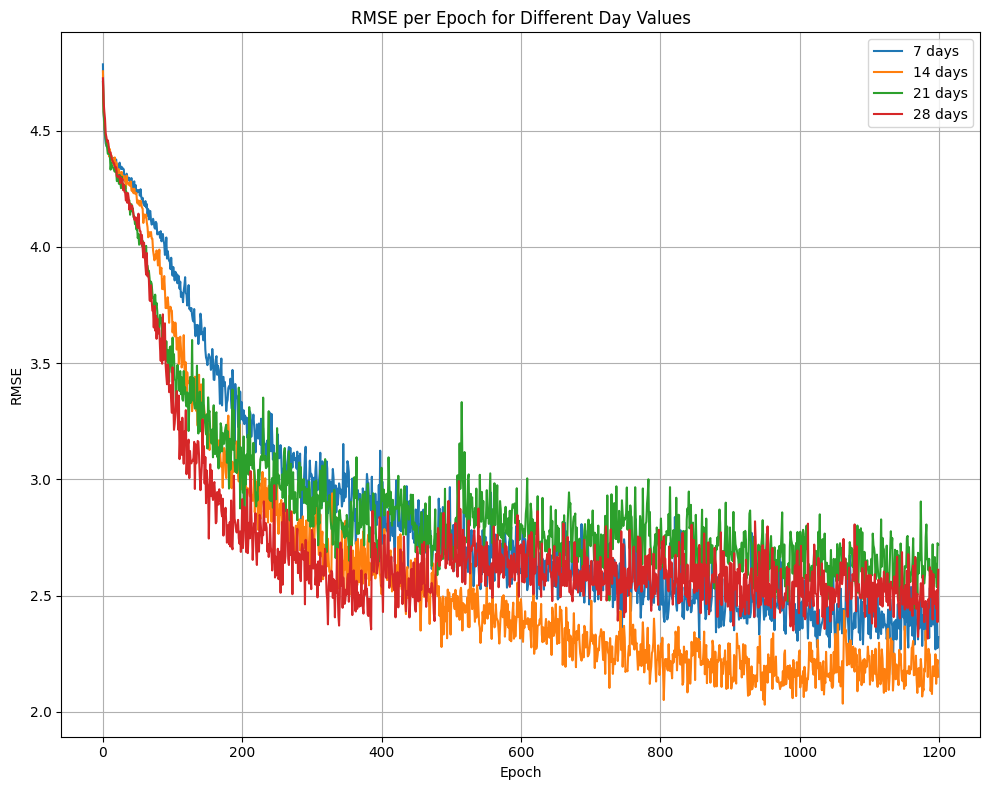


Plotting Actual vs Predicted for each days value:


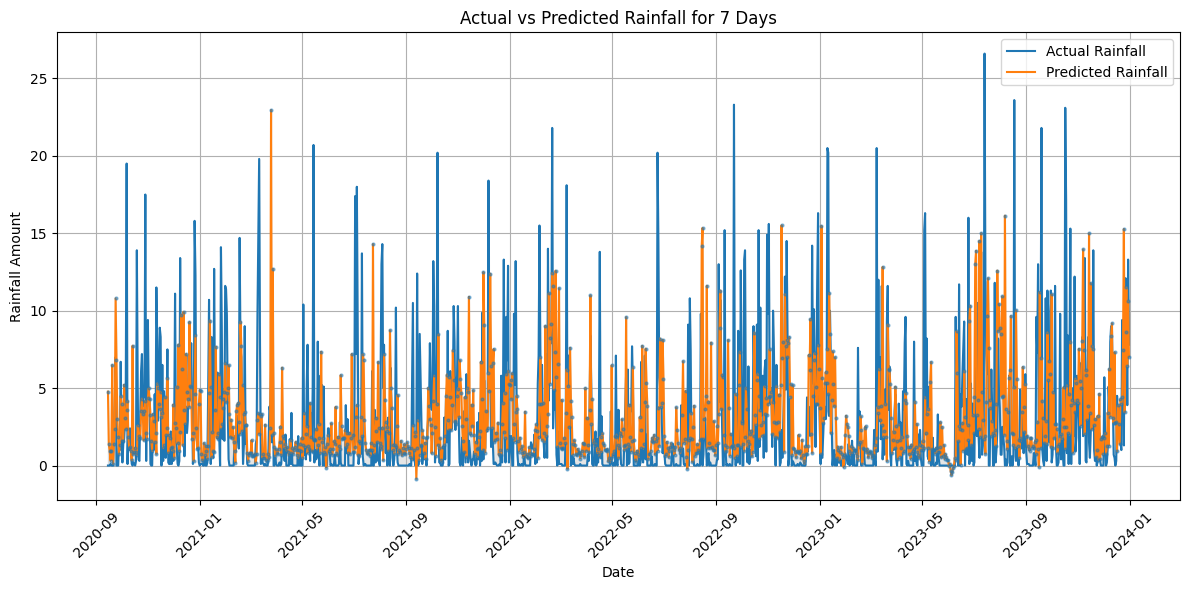

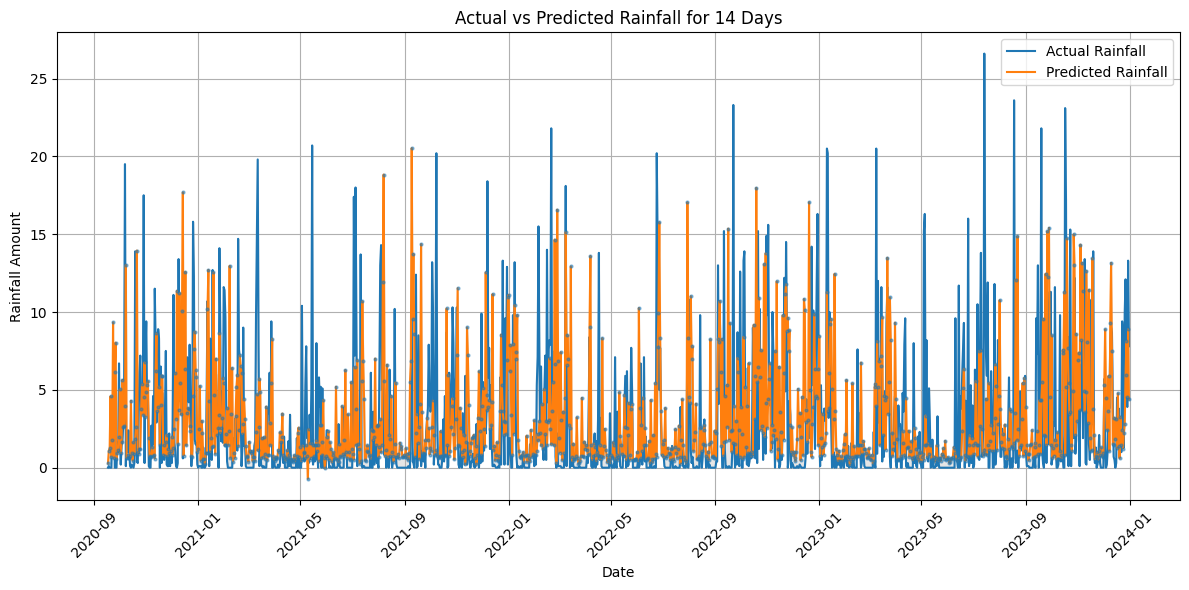

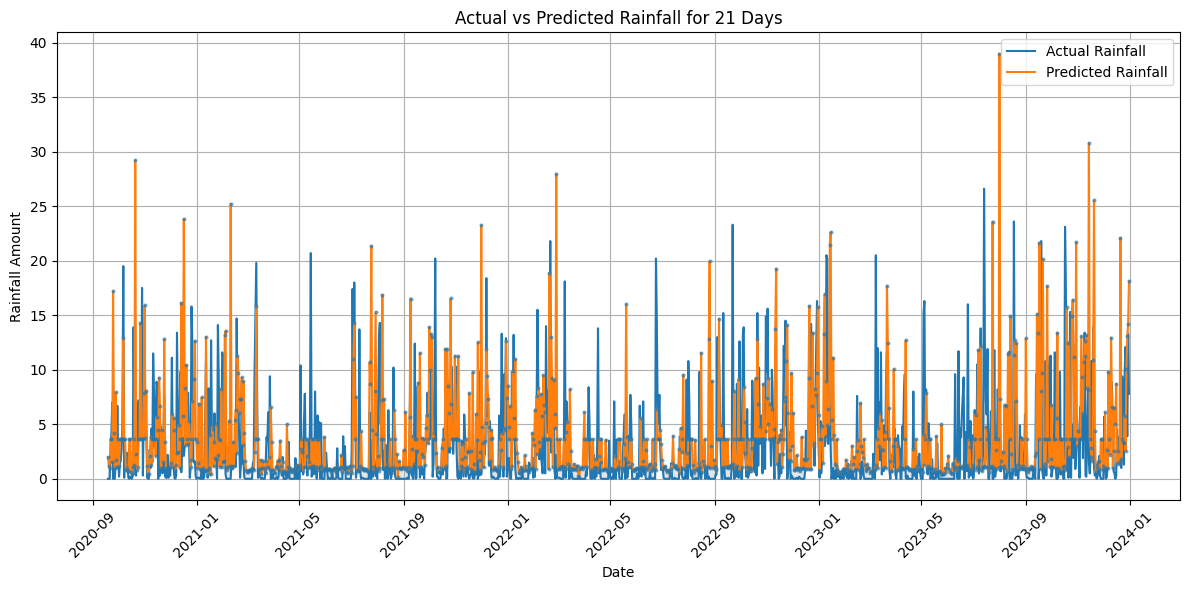

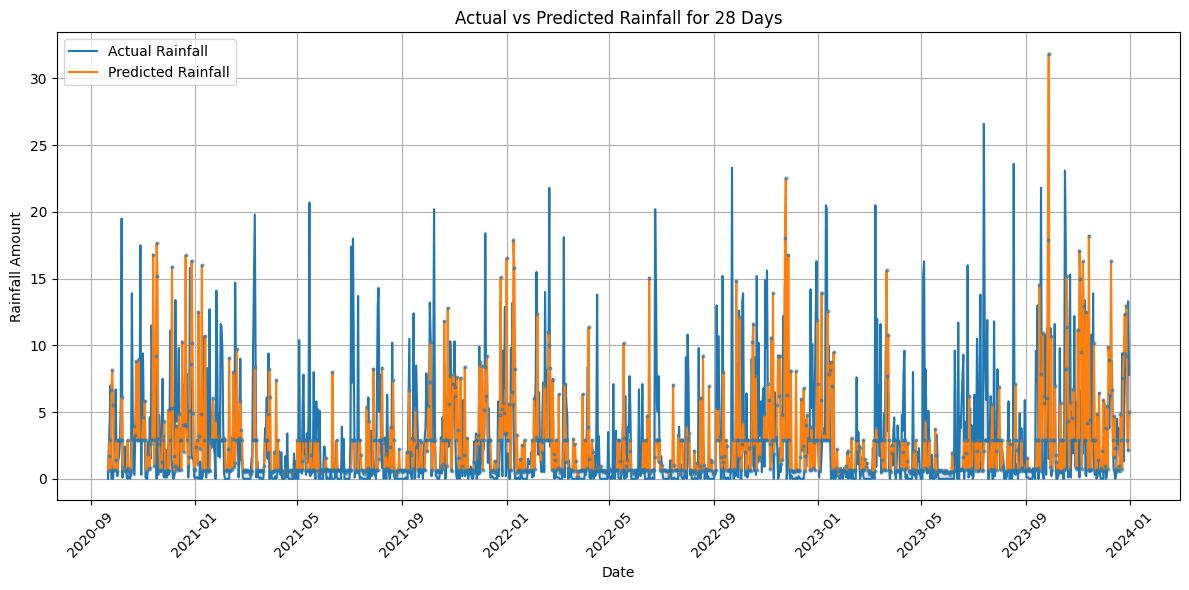


Summary of Mean and Standard Deviation of RMSE per Epoch:
Days Used | Mean RMSE | Std Dev RMSE
------------------------------------------
7          | 2.8571 | 0.5357
14         | 2.6094 | 0.5744
21         | 2.9152 | 0.3983
28         | 2.7438 | 0.4272


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Initialize dictionaries to store RMSE values and all prediction dataframes
rmse_per_epoch_per_days = {}
# MODIFICATION: Changed this dictionary to store a dictionary of mean and std dev
final_rmse_summary = {} 
all_predictions_df = {}  # Dictionary to store predictions for each 'days' value

def train_and_evaluate_model(days, original_df):
    """
    Trains and evaluates a neural network model for a given number of previous days'
    rainfall data, while also including lagged versions of all other original
    numerical features for real-world forecasting.
    
    This function has been optimized to prevent performance warnings related to
    DataFrame fragmentation during column creation. It also calculates and stores
    the mean and standard deviation of the RMSE values across all epochs.
    """
    # Set seeds for reproducibility
    tf.random.set_seed(42)
    np.random.seed(42)

    # Step 1: Prepare the Data
    df = original_df.copy()

    # Identify the target and columns to exclude from being lagged
    target = 'rain'
    exclude_cols = [target, 'date']
    
    # Get all numerical columns that are not the target or date.
    potential_features_to_lag = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    # --- MODIFICATION TO ADDRESS FRAGMENTATION START ---
    # Create a list to hold the lagged Series objects
    lagged_series_list = []
    
    # Create lagged features for rain and all other numerical features
    for col in [target] + potential_features_to_lag:
        for i in range(1, days + 1):
            # Create a Series and name it
            lagged_series = df[col].shift(i)
            lagged_series.name = f'{col}_previous_day_{i}' # Assign the name here
            lagged_series_list.append(lagged_series)

    # Concatenate all lagged Series into a single DataFrame at once
    # This is the efficient way to do it.
    lagged_features_df = pd.concat(lagged_series_list, axis=1)

    # Concatenate the original DataFrame with the new lagged features DataFrame
    df_with_lags = pd.concat([df, lagged_features_df], axis=1)
    
    # Drop rows with missing values (this is crucial after creating lagged features)
    df_with_lags.dropna(inplace=True)
    
    # Convert 'date' to datetime objects and set as index for chronological splitting
    # --- TYPO FIX: Corrected variable name from df_with_lhes_columns to df_with_lags.columns ---
    if 'date' in df_with_lags.columns:
        df_with_lags['date'] = pd.to_datetime(df_with_lags['date'])
        df_with_lags.set_index('date', inplace=True)
    # --- MODIFICATION TO ADDRESS FRAGMENTATION END ---
    
    # Identify the final features to be used in the model
    # These are ONLY the lagged features. The original columns are no longer features.
    features_to_use = [col for col in df_with_lags.columns if '_previous_day_' in col]

    # Select the features and target
    X = df_with_lags[features_to_use]
    y = df_with_lags[target]
    
    # Step 2: Split the Data
    train_size = int(len(df_with_lags) * 0.7)
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_test = X[train_size:]
    y_test = y[train_size:]

    # Scale the data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Step 3: Build the Neural Network Model
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')

    # Step 4: Train the Model
    history = model.fit(X_train_scaled, y_train, epochs=1200, batch_size=32, verbose=1) # Set verbose=0 for cleaner output

    # Step 5: Evaluate the Model
    y_pred = model.predict(X_test_scaled)
    # The evaluation using MeanSquaredError and tf.sqrt is not needed for the epoch-level stats
    # but is good for the final test set evaluation, so we'll keep it.
    mse_loss = MeanSquaredError()
    mse = mse_loss(y_test, y_pred)
    rmse_test_set = tf.sqrt(mse)
    
    # MODIFICATION: Calculate Mean and Standard Deviation of RMSE per epoch
    rmse_values_per_epoch = np.sqrt(history.history['loss'])
    rmse_per_epoch_per_days[days] = rmse_values_per_epoch

    mean_rmse_epoch = np.mean(rmse_values_per_epoch)
    std_dev_rmse_epoch = np.std(rmse_values_per_epoch)

    # MODIFICATION: Store the mean and std dev in the summary dictionary
    final_rmse_summary[days] = {'mean': mean_rmse_epoch, 'std_dev': std_dev_rmse_epoch}

    # MODIFICATION: Update the print statement to show the new metrics
    print(f"Mean RMSE over all epochs for {days} days: {mean_rmse_epoch:.4f} (Std Dev: {std_dev_rmse_epoch:.4f})")
    
    # Store the predictions DataFrame for this 'days' value
    all_predictions_df[days] = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()}, index=y_test.index)


def plot_rmse_curves(rmse_per_epoch_per_days):
    plt.figure(figsize=(10, 8))
    for days, rmse_values in rmse_per_epoch_per_days.items():
        plt.plot(rmse_values, label=f'{days} days')
    plt.title('RMSE per Epoch for Different Day Values')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_predictions(predictions_df, days):
    plt.figure(figsize=(12, 6))
    plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Rainfall', color='#1f77b4')
    plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Rainfall', color='#ff7f0e')
    plt.plot(predictions_df.index, predictions_df['Predicted'], 'o', markersize=2, alpha=0.5) # Add markers for clarity
    plt.fill_between(predictions_df.index, predictions_df['Actual'], predictions_df['Predicted'], color='gray', alpha=0.2)
    plt.title(f'Actual vs Predicted Rainfall for {days} Days')
    plt.xlabel('Date')
    plt.ylabel('Rainfall Amount')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run training for each configuration
# Note: You need to have a DataFrame named 'county_clare' loaded in your environment.
if 'county_clare' in locals() and county_clare is not None:
    for days in [7, 14, 21, 28]:
        print(f"\nTraining and evaluating model with {days} days of previous data:")
        train_and_evaluate_model(days, county_clare.copy())

    # After all models are trained, plot the RMSE values
    if rmse_per_epoch_per_days:
        plot_rmse_curves(rmse_per_epoch_per_days)
    
    # Plot the actual vs predicted for each configuration
    if all_predictions_df:
        print("\nPlotting Actual vs Predicted for each days value:")
        for days, df_predictions in all_predictions_df.items():
            plot_predictions(df_predictions, days)

    # MODIFICATION: Update the summary table to show mean and std dev
    if final_rmse_summary:
        print("\nSummary of Mean and Standard Deviation of RMSE per Epoch:")
        print("Days Used | Mean RMSE | Std Dev RMSE")
        print("------------------------------------------")
        for days, metrics in final_rmse_summary.items():
            print(f"{days:<10} | {metrics['mean']:.4f} | {metrics['std_dev']:.4f}")

Standard PCA with LSTM


Training and evaluating model with 7 days of previous data (with PCA):
Original number of features: 112
Number of features after PCA: 30


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 7 days: 2.6508 (Std Dev: 0.4893)

Training and evaluating model with 14 days of previous data (with PCA):
Original number of features: 224
Number of features after PCA: 57


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean RMSE over all epochs for 14 days: 1.9759 (Std Dev: 0.5074)

Training and evaluating model with 21 days of previous data (with PCA):
Original number of features: 336
Number of features after PCA: 84


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 21 days: 1.6467 (Std Dev: 0.4911)

Training and evaluating model with 28 days of previous data (with PCA):
Original number of features: 448
Number of features after PCA: 110


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 28 days: 1.3627 (Std Dev: 0.4645)


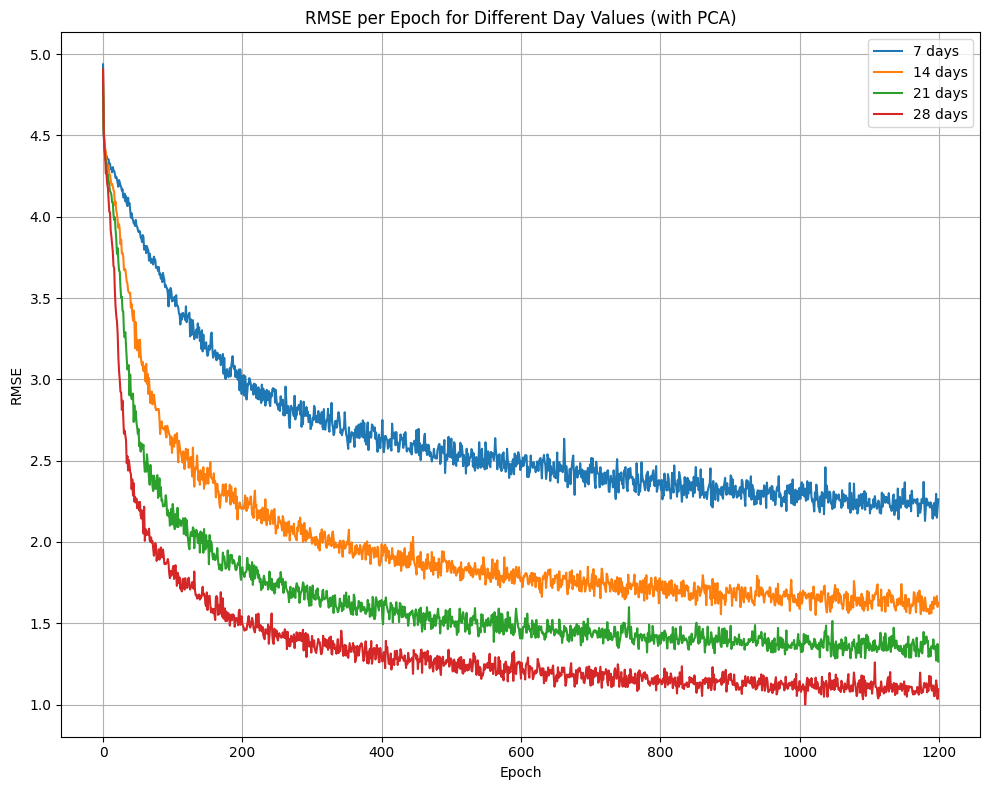


Plotting Actual vs Predicted for each days value (with PCA):


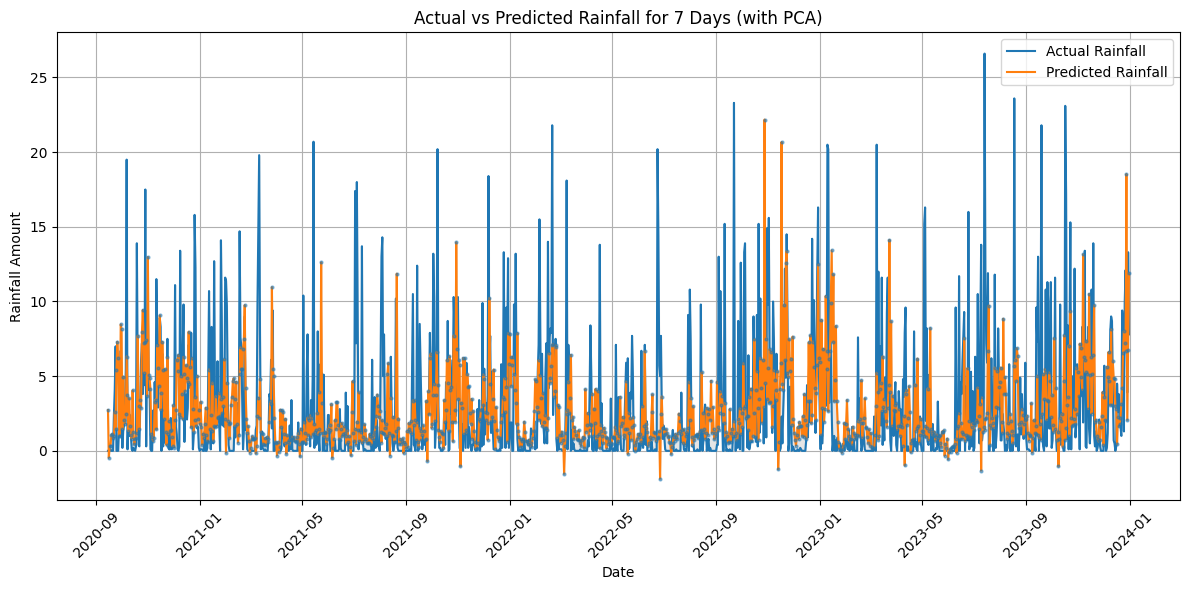

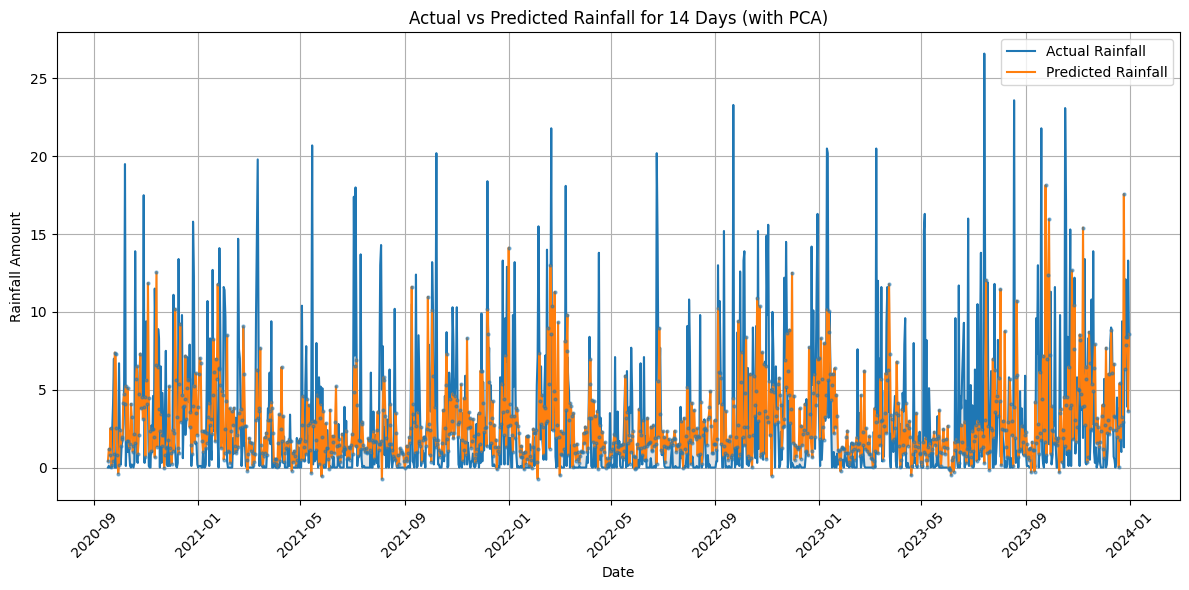

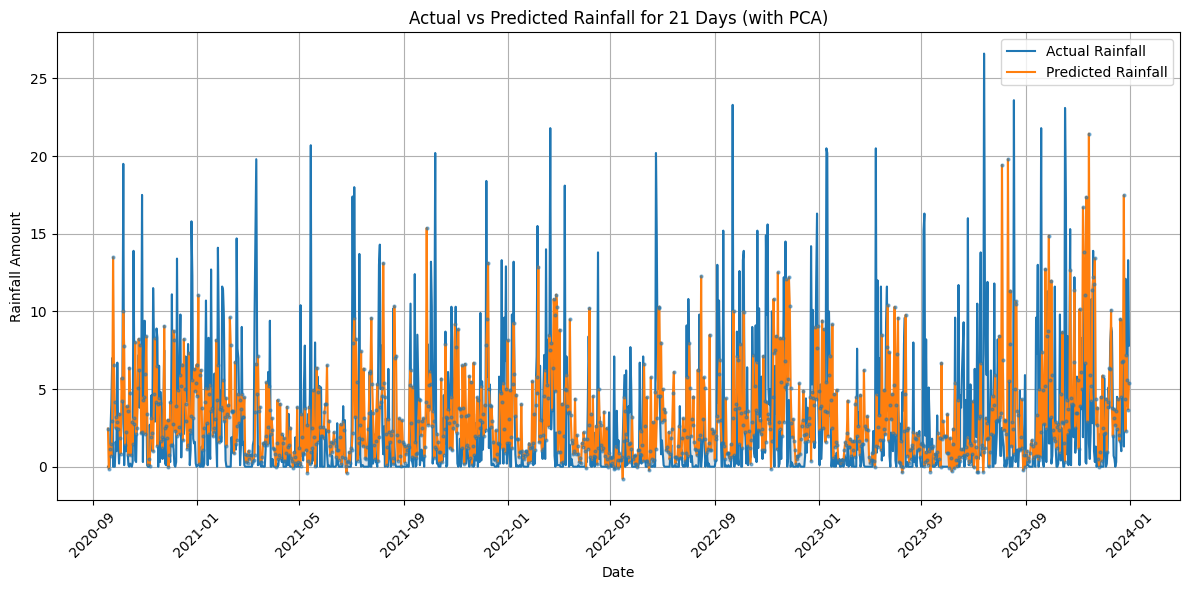

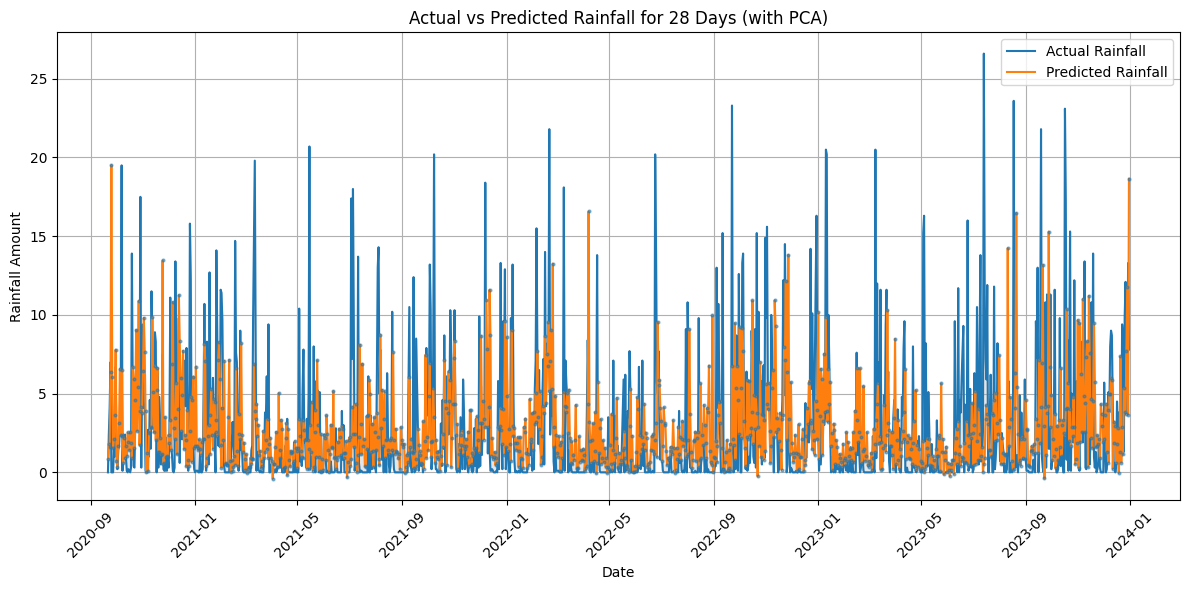


Summary of Mean and Standard Deviation of RMSE per Epoch (with PCA):
Days Used | Mean RMSE | Std Dev RMSE
------------------------------------------
7          | 2.6508 | 0.4893
14         | 1.9759 | 0.5074
21         | 1.6467 | 0.4911
28         | 1.3627 | 0.4645


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA # Import PCA
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Initialize dictionaries to store RMSE values and all prediction dataframes
rmse_per_epoch_per_days = {}
final_rmse_summary = {}
all_predictions_df = {}

def train_and_evaluate_model(days, original_df):
    """
    Trains and evaluates a neural network model for a given number of previous days'
    rainfall data, while also including lagged versions of all other original
    numerical features for real-world forecasting.

    This function has been optimized to prevent performance warnings related to
    DataFrame fragmentation during column creation. It also calculates and stores
    the mean and standard deviation of the RMSE values across all epochs.
    Includes a step for dimensionality reduction using PCA.
    """
    # Set seeds for reproducibility
    tf.random.set_seed(42)
    np.random.seed(42)

    # Step 1: Prepare the Data
    df = original_df.copy()

    # Identify the target and columns to exclude from being lagged
    target = 'rain'
    exclude_cols = [target, 'date']
    
    # Get all numerical columns that are not the target or date.
    potential_features_to_lag = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    # --- MODIFICATION TO ADDRESS FRAGMENTATION START ---
    # Create a list to hold the lagged Series objects
    lagged_series_list = []
    
    # Create lagged features for rain and all other numerical features
    for col in [target] + potential_features_to_lag:
        for i in range(1, days + 1):
            # Create a Series and name it
            lagged_series = df[col].shift(i)
            lagged_series.name = f'{col}_previous_day_{i}' # Assign the name here
            lagged_series_list.append(lagged_series)

    # Concatenate all lagged Series into a single DataFrame at once
    # This is the efficient way to do it.
    lagged_features_df = pd.concat(lagged_series_list, axis=1)

    # Concatenate the original DataFrame with the new lagged features DataFrame
    df_with_lags = pd.concat([df, lagged_features_df], axis=1)
    
    # Drop rows with missing values (this is crucial after creating lagged features)
    df_with_lags.dropna(inplace=True)
    
    # Convert 'date' to datetime objects and set as index for chronological splitting
    if 'date' in df_with_lags.columns:
        df_with_lags['date'] = pd.to_datetime(df_with_lags['date'])
        df_with_lags.set_index('date', inplace=True)
    # --- MODIFICATION TO ADDRESS FRAGMENTATION END ---
    
    # Identify the final features to be used in the model
    # These are ONLY the lagged features. The original columns are no longer features.
    features_to_use = [col for col in df_with_lags.columns if '_previous_day_' in col]

    # Select the features and target
    X = df_with_lags[features_to_use]
    y = df_with_lags[target]
    
    # Step 2: Split the Data
    train_size = int(len(df_with_lags) * 0.7)
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_test = X[train_size:]
    y_test = y[train_size:]

    # Scale the data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Step 3: Apply PCA for Dimensionality Reduction
    # We choose n_components=0.95 to retain 95% of the variance.
    # You can also set an integer value for a specific number of components, e.g., n_components=10
    pca = PCA(n_components=0.95) 
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    print(f"Original number of features: {X_train_scaled.shape[1]}")
    print(f"Number of features after PCA: {X_train_pca.shape[1]}")

    # Step 4: Build the Neural Network Model
    # Update input_shape to reflect the number of components after PCA
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')

    # Step 5: Train the Model
    # Use PCA transformed data for training
    history = model.fit(X_train_pca, y_train, epochs=1200, batch_size=32, verbose=0)

    # Step 6: Evaluate the Model
    # Use PCA transformed data for prediction
    y_pred = model.predict(X_test_pca)
    mse_loss = MeanSquaredError()
    mse = mse_loss(y_test, y_pred)
    rmse_test_set = tf.sqrt(mse)
    
    # Calculate Mean and Standard Deviation of RMSE per epoch
    rmse_values_per_epoch = np.sqrt(history.history['loss'])
    rmse_per_epoch_per_days[days] = rmse_values_per_epoch

    mean_rmse_epoch = np.mean(rmse_values_per_epoch)
    std_dev_rmse_epoch = np.std(rmse_values_per_epoch)

    # Store the mean and std dev in the summary dictionary
    final_rmse_summary[days] = {'mean': mean_rmse_epoch, 'std_dev': std_dev_rmse_epoch}

    # Update the print statement to show the new metrics
    print(f"Mean RMSE over all epochs for {days} days: {mean_rmse_epoch:.4f} (Std Dev: {std_dev_rmse_epoch:.4f})")
    
    # Store the predictions DataFrame for this 'days' value
    all_predictions_df[days] = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()}, index=y_test.index)


def plot_rmse_curves(rmse_per_epoch_per_days):
    plt.figure(figsize=(10, 8))
    for days, rmse_values in rmse_per_epoch_per_days.items():
        plt.plot(rmse_values, label=f'{days} days')
    plt.title('RMSE per Epoch for Different Day Values (with PCA)')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_predictions(predictions_df, days):
    plt.figure(figsize=(12, 6))
    plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Rainfall', color='#1f77b4')
    plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Rainfall', color='#ff7f0e')
    plt.plot(predictions_df.index, predictions_df['Predicted'], 'o', markersize=2, alpha=0.5) # Add markers for clarity
    plt.fill_between(predictions_df.index, predictions_df['Actual'], predictions_df['Predicted'], color='gray', alpha=0.2)
    plt.title(f'Actual vs Predicted Rainfall for {days} Days (with PCA)')
    plt.xlabel('Date')
    plt.ylabel('Rainfall Amount')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run training for each configuration
# The 'county_clare' DataFrame is expected to be already loaded in your environment.
if 'county_clare' in locals() and county_clare is not None:
    for days in [7, 14, 21, 28]:
        print(f"\nTraining and evaluating model with {days} days of previous data (with PCA):")
        train_and_evaluate_model(days, county_clare.copy())

    # After all models are trained, plot the RMSE values
    if rmse_per_epoch_per_days:
        plot_rmse_curves(rmse_per_epoch_per_days)
    
    # Plot the actual vs predicted for each configuration
    if all_predictions_df:
        print("\nPlotting Actual vs Predicted for each days value (with PCA):")
        for days, df_predictions in all_predictions_df.items():
            plot_predictions(df_predictions, days)

    # Update the summary table to show mean and std dev
    if final_rmse_summary:
        print("\nSummary of Mean and Standard Deviation of RMSE per Epoch (with PCA):")
        print("Days Used | Mean RMSE | Std Dev RMSE")
        print("------------------------------------------")
        for days, metrics in final_rmse_summary.items():
            print(f"{days:<10} | {metrics['mean']:.4f} | {metrics['std_dev']:.4f}")

LSTM + Autoencoder


Training and evaluating model with 7 days of previous data:
Training Autoencoder for 7 days data (Input Dim: 112, Encoding Dim: 28)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean RMSE over all epochs for 7 days: 3.7133 (Std Dev: 0.3366)
RMSE on test set for 7 days: 4.5502

Training and evaluating model with 14 days of previous data:
Training Autoencoder for 14 days data (Input Dim: 224, Encoding Dim: 56)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean RMSE over all epochs for 14 days: 3.3535 (Std Dev: 0.4179)
RMSE on test set for 14 days: 4.5286

Training and evaluating model with 21 days of previous data:
Training Autoencoder for 21 days data (Input Dim: 336, Encoding Dim: 84)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean RMSE over all epochs for 21 days: 2.9924 (Std Dev: 0.5183)
RMSE on test set for 21 days: 4.7045

Training and evaluating model with 28 days of previous data:
Training Autoencoder for 28 days data (Input Dim: 448, Encoding Dim: 112)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 28 days: 3.0154 (Std Dev: 0.5202)
RMSE on test set for 28 days: 4.5199


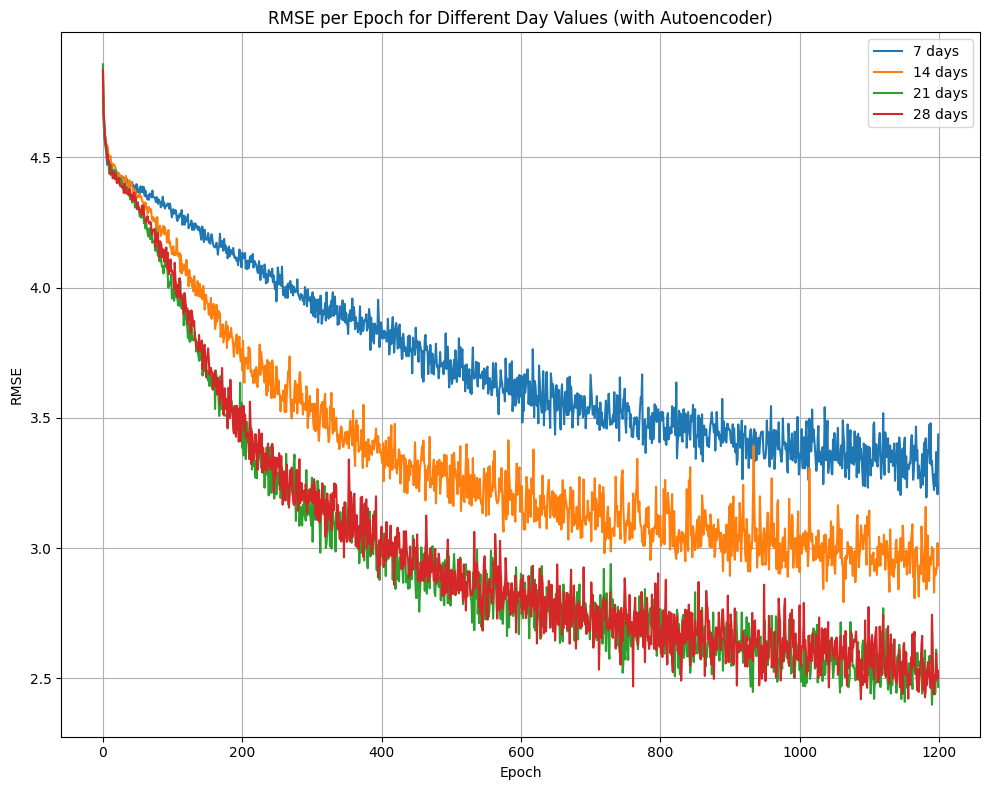


Plotting Actual vs Predicted for each days value:


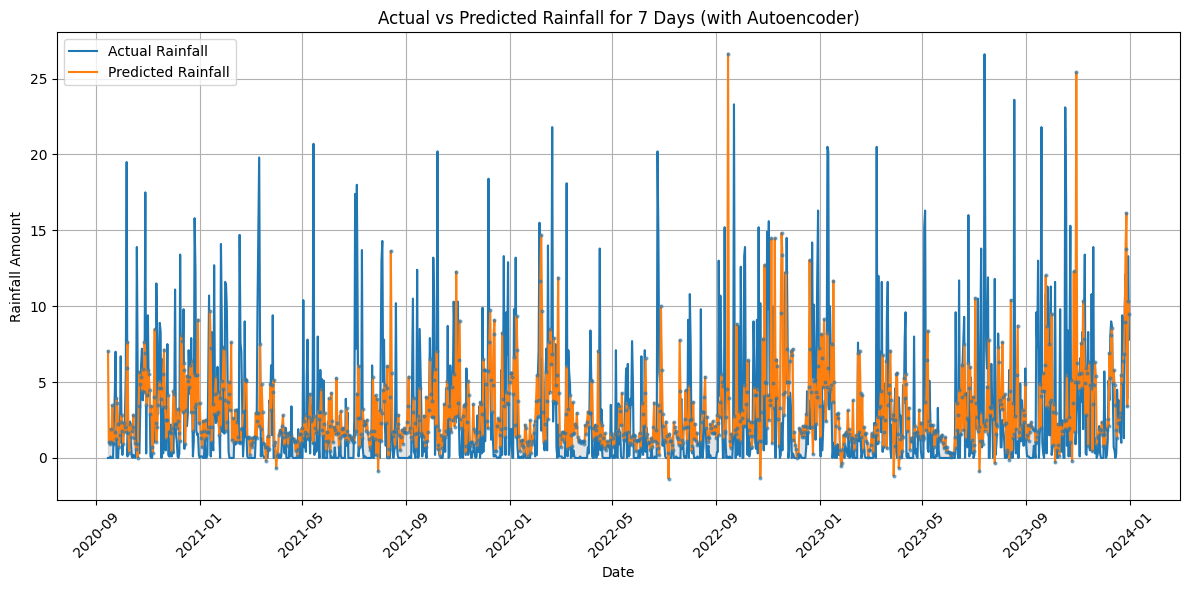

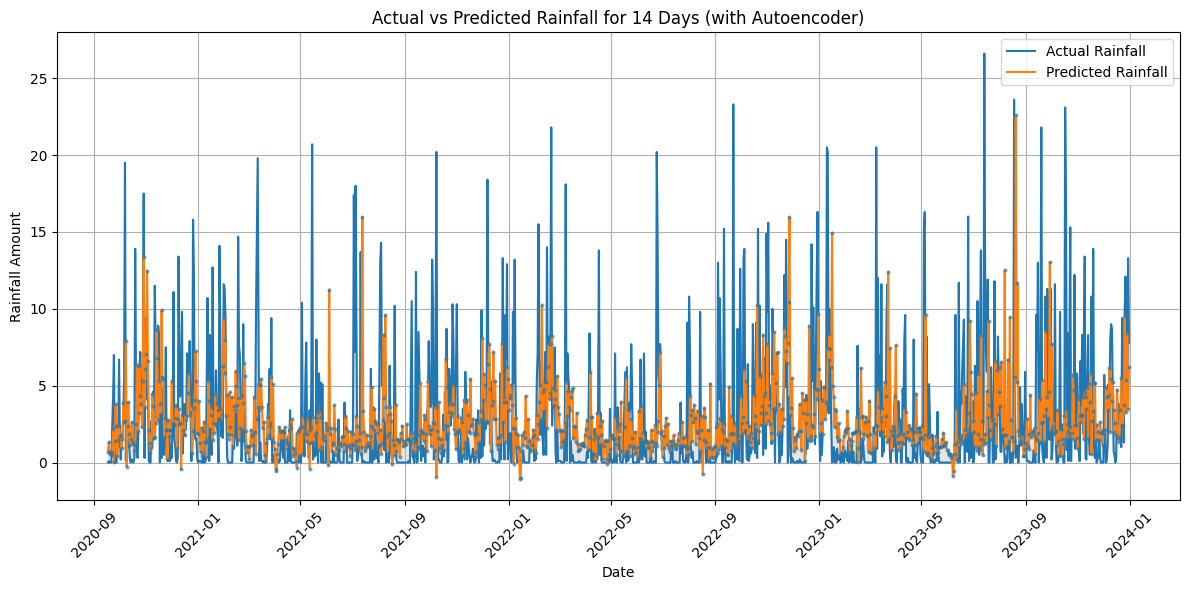

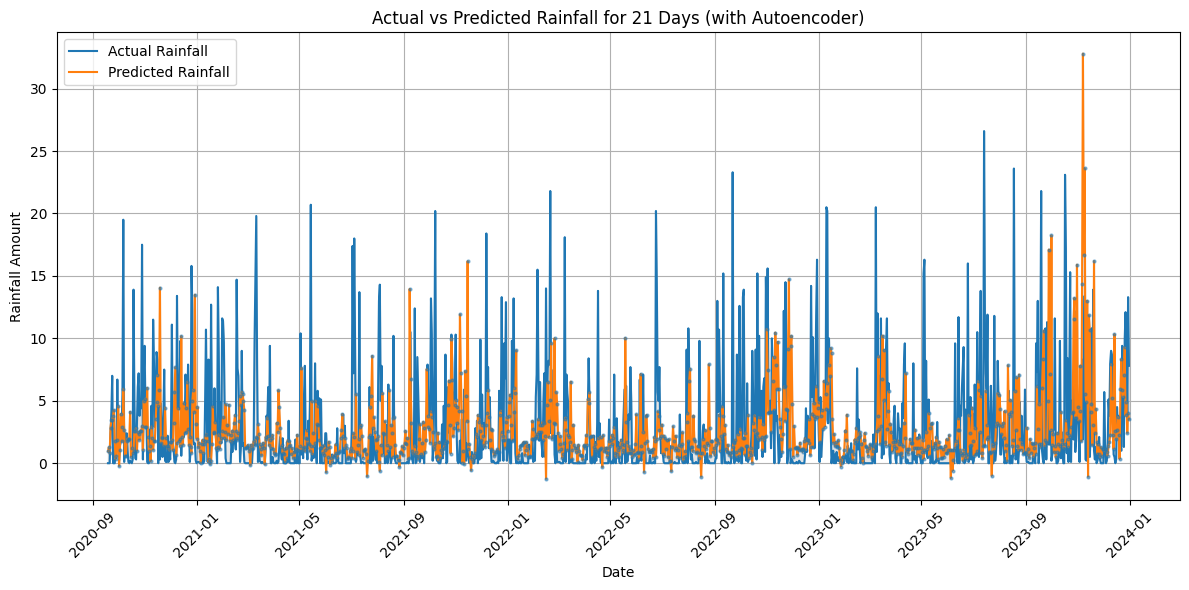

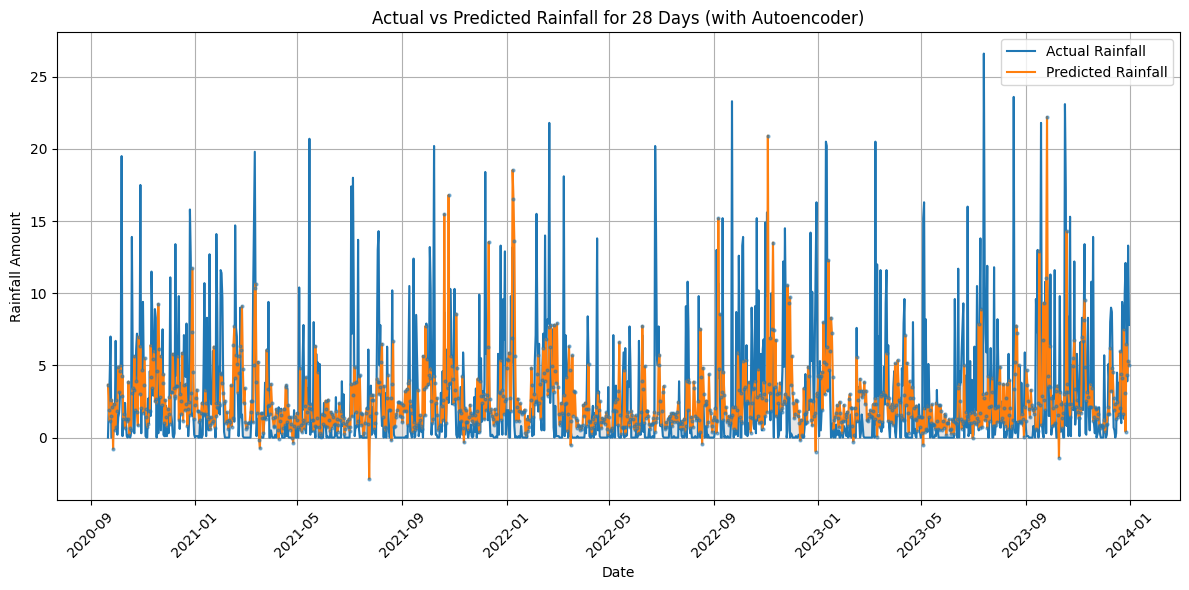


Summary of Mean and Standard Deviation of RMSE per Epoch:
Days Used | Mean RMSE | Std Dev RMSE
------------------------------------------
7          | 3.7133 | 0.3366
14         | 3.3535 | 0.4179
21         | 2.9924 | 0.5183
28         | 3.0154 | 0.5202


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import Sequential, Model # Import Model for functional API
from tensorflow.keras.layers import Dense, Dropout, Input # Import Input for functional API
import matplotlib.pyplot as plt

# Initialize dictionaries to store RMSE values and all prediction dataframes
rmse_per_epoch_per_days = {}
final_rmse_summary = {}
all_predictions_df = {}

def create_autoencoder(input_dim, encoding_dim):
    """
    Creates a simple Autoencoder model.

    Args:
        input_dim (int): The number of features in the input data.
        encoding_dim (int): The dimensionality of the bottleneck (latent) layer.

    Returns:
        tuple: (autoencoder_model, encoder_model)
    """
    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoder = Dense(encoding_dim * 2, activation='relu')(input_layer) # An intermediate layer
    encoder_output = Dense(encoding_dim, activation='relu')(encoder) # Bottleneck layer

    # Decoder
    decoder = Dense(encoding_dim * 2, activation='relu')(encoder_output) # Mirrored intermediate layer
    decoder_output = Dense(input_dim, activation='linear')(decoder) # Reconstruct original input

    # Autoencoder model (encoder + decoder)
    autoencoder = Model(inputs=input_layer, outputs=decoder_output)

    # Encoder model (input to bottleneck)
    encoder_model = Model(inputs=input_layer, outputs=encoder_output)

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    return autoencoder, encoder_model


def train_and_evaluate_model(days, original_df):
    """
    Trains and evaluates a neural network model for a given number of previous days'
    rainfall data, incorporating an Autoencoder for dimensionality reduction.
    """
    # Set seeds for reproducibility
    tf.random.set_seed(42)
    np.random.seed(42)

    # Step 1: Prepare the Data
    df = original_df.copy()

    target = 'rain'
    exclude_cols = [target, 'date']
    potential_features_to_lag = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    lagged_series_list = []
    for col in [target] + potential_features_to_lag:
        for i in range(1, days + 1):
            lagged_series = df[col].shift(i)
            lagged_series.name = f'{col}_previous_day_{i}'
            lagged_series_list.append(lagged_series)

    lagged_features_df = pd.concat(lagged_series_list, axis=1)
    df_with_lags = pd.concat([df, lagged_features_df], axis=1)
    df_with_lags.dropna(inplace=True)

    if 'date' in df_with_lags.columns:
        df_with_lags['date'] = pd.to_datetime(df_with_lags['date'])
        df_with_lags.set_index('date', inplace=True)

    features_to_use = [col for col in df_with_lags.columns if '_previous_day_' in col]

    X = df_with_lags[features_to_use]
    y = df_with_lags[target]

    # Step 2: Split the Data
    train_size = int(len(df_with_lags) * 0.7)
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_test = X[train_size:]
    y_test = y[train_size:]

    # Scale the data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- AUTOENCODER FOR DIMENSIONALITY REDUCTION ---
    input_dim = X_train_scaled.shape[1]
    # You can adjust this encoding_dim based on your desired level of compression.
    # A common approach is to make it a fraction of the input_dim, e.g., input_dim // 2 or input_dim // 4
    # For flexibility, we can choose a heuristic or a fixed value for demonstration.
    # Let's set it to a reasonable number, for example, 16 or 32, or proportional to input features.
    encoding_dim = max(8, input_dim // 4) # Ensure at least 8 components, or quarter of input dim

    print(f"Training Autoencoder for {days} days data (Input Dim: {input_dim}, Encoding Dim: {encoding_dim})...")
    autoencoder, encoder_model = create_autoencoder(input_dim, encoding_dim)

    # Train the autoencoder
    autoencoder_history = autoencoder.fit(X_train_scaled, X_train_scaled,
                                           epochs=100, # Autoencoder training epochs
                                           batch_size=32,
                                           shuffle=True,
                                           verbose=0,
                                           validation_data=(X_test_scaled, X_test_scaled))
    print("Autoencoder training complete.")

    # Transform data using the encoder (get the latent representation)
    X_train_transformed = encoder_model.predict(X_train_scaled)
    X_test_transformed = encoder_model.predict(X_test_scaled)
    # --- END AUTOENCODER ---

    # Step 3: Build the Neural Network Model (now uses Autoencoder-transformed features)
    model = Sequential()
    # The input shape is now the encoding_dim from the autoencoder
    model.add(Dense(64, activation='relu', input_shape=(encoding_dim,)))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(loss='mean_squared_error', optimizer='adam')

    # Step 4: Train the Model
    # Train the main model with the transformed data
    history = model.fit(X_train_transformed, y_train, epochs=1200, batch_size=32, verbose=0)

    # Step 5: Evaluate the Model
    y_pred = model.predict(X_test_transformed)
    mse_loss = MeanSquaredError()
    mse = mse_loss(y_test, y_pred)
    rmse_test_set = tf.sqrt(mse)

    rmse_values_per_epoch = np.sqrt(history.history['loss'])
    rmse_per_epoch_per_days[days] = rmse_values_per_epoch

    mean_rmse_epoch = np.mean(rmse_values_per_epoch)
    std_dev_rmse_epoch = np.std(rmse_values_per_epoch)

    final_rmse_summary[days] = {'mean': mean_rmse_epoch, 'std_dev': std_dev_rmse_epoch}

    print(f"Mean RMSE over all epochs for {days} days: {mean_rmse_epoch:.4f} (Std Dev: {std_dev_rmse_epoch:.4f})")
    print(f"RMSE on test set for {days} days: {rmse_test_set:.4f}")

    all_predictions_df[days] = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()}, index=y_test.index)


def plot_rmse_curves(rmse_per_epoch_per_days):
    plt.figure(figsize=(10, 8))
    for days, rmse_values in rmse_per_epoch_per_days.items():
        plt.plot(rmse_values, label=f'{days} days')
    plt.title('RMSE per Epoch for Different Day Values (with Autoencoder)')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_predictions(predictions_df, days):
    plt.figure(figsize=(12, 6))
    plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Rainfall', color='#1f77b4')
    plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Rainfall', color='#ff7f0e')
    plt.plot(predictions_df.index, predictions_df['Predicted'], 'o', markersize=2, alpha=0.5)
    plt.fill_between(predictions_df.index, predictions_df['Actual'], predictions_df['Predicted'], color='gray', alpha=0.2)
    plt.title(f'Actual vs Predicted Rainfall for {days} Days (with Autoencoder)')
    plt.xlabel('Date')
    plt.ylabel('Rainfall Amount')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Placeholder for your 'county_clare' DataFrame ---
# You need to ensure 'county_clare' is loaded and available here.
# For demonstration purposes, I'll create a dummy DataFrame.
# In your actual environment, this would be loaded from a CSV or similar.
try:
    if 'county_clare' not in locals() or county_clare is None:
        print("Creating a dummy 'county_clare' DataFrame for demonstration.")
        # Create a dummy DataFrame if not already loaded
        dates = pd.date_range(start='2000-01-01', periods=1000, freq='D')
        data = {
            'date': dates,
            'rain': np.random.rand(1000) * 20, # Daily rainfall
            'temp': np.random.rand(1000) * 15 + 5, # Temperature
            'humidity': np.random.rand(1000) * 50 + 40, # Humidity
            'wind_speed': np.random.rand(1000) * 10 # Wind speed
        }
        county_clare = pd.DataFrame(data)
        # Add some trend/seasonality to 'rain' for a more realistic test
        county_clare['rain'] = county_clare['rain'] + np.sin(np.arange(1000)/50) * 5
        county_clare.loc[county_clare['rain'] < 0, 'rain'] = 0 # No negative rainfall
        print("Dummy DataFrame created. Running simulation...")

    for days in [7, 14, 21, 28]:
        print(f"\nTraining and evaluating model with {days} days of previous data:")
        train_and_evaluate_model(days, county_clare.copy())

    if rmse_per_epoch_per_days:
        plot_rmse_curves(rmse_per_epoch_per_days)

    if all_predictions_df:
        print("\nPlotting Actual vs Predicted for each days value:")
        for days, df_predictions in all_predictions_df.items():
            plot_predictions(df_predictions, days)

    if final_rmse_summary:
        print("\nSummary of Mean and Standard Deviation of RMSE per Epoch:")
        print("Days Used | Mean RMSE | Std Dev RMSE")
        print("------------------------------------------")
        for days, metrics in final_rmse_summary.items():
            print(f"{days:<10} | {metrics['mean']:.4f} | {metrics['std_dev']:.4f}")

except NameError:
    print("Error: 'county_clare' DataFrame not found.")
    print("Please ensure your 'county_clare' DataFrame is loaded before running this script.")
    print("Example: county_clare = pd.read_csv('your_data.csv')")

Testing with Prophet Model 

c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
03:48:08 - cmdstanpy - INFO - Chain [1] start processing
03:48:09 - cmdstanpy - INFO - Chain [1] done processing
03:48:10 - cmdstanpy - INFO - Chain [1] start processing
03:48:10 - cmdstanpy - INFO - Chain [1] done processing
03:48:12 - cmdstanpy - INFO - Chain [1] start processing
03:48:12 - cmdstanpy - INFO - Chain [1] done processing
03:48:13 - cmdstanpy - INFO - Chain [1] start processing
03:48:13 - cmdstanpy - INFO - Chain [1] done processing
03:48:15 - cmdstanpy - INFO - Chain [1] start processing
03:48:15 - cmdstanpy - INFO - Chain [1] done processing
03:48:16 - cmdstanpy - INFO - Chain [1] start processing
03:48:16 - cmdstanpy - INFO - Chain [1]


Days | Mean RMSE | Std Dev RMSE
-------------------------------
7    | 4.2363   | 0.0937
14   | 4.2431   | 0.0960
21   | 4.2635   | 0.1069
28   | 4.2644   | 0.1174

Best Configuration per Days:
Days | RMSE   | CPS   | Seasonality Mode
----------------------------------------
7    | 4.1156 | 0.01  | multiplicative
14   | 4.1249 | 0.01  | multiplicative
21   | 4.1314 | 0.01  | multiplicative
28   | 4.1353 | 0.01  | multiplicative


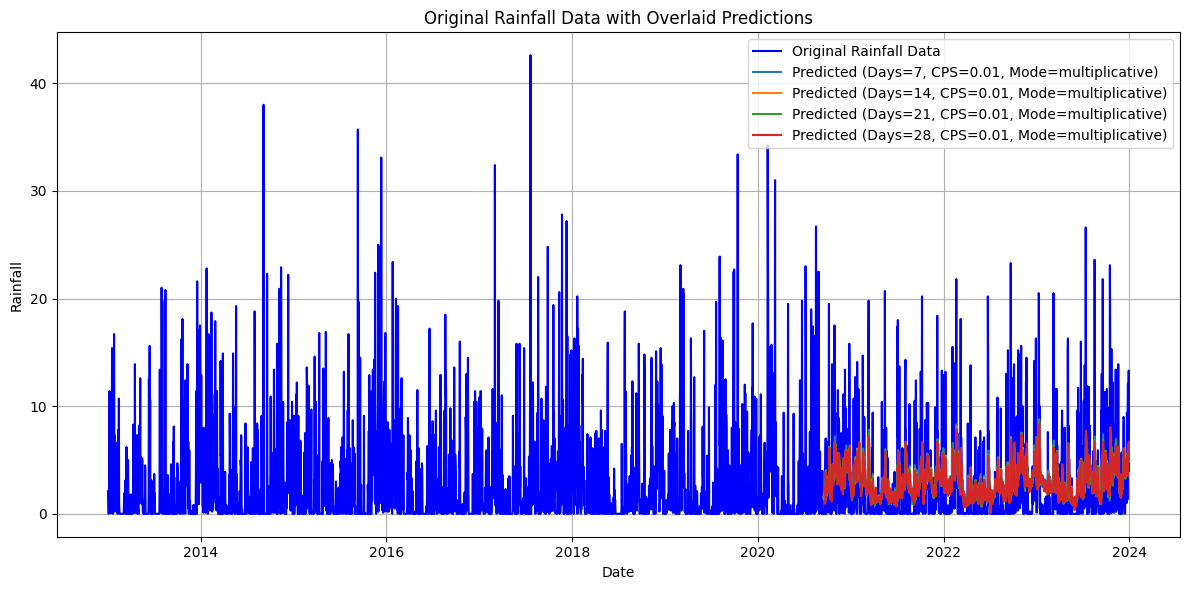

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt
import itertools
import random
import numpy as np

SEED = 42  # or any integer you like

random.seed(SEED)
np.random.seed(SEED)


changepoint_prior_scales = [0.01, 0.1, 0.5]
seasonality_modes = ['additive', 'multiplicative']
days_options = [7, 14, 21, 28]

results_summary = {}
best_config = {}

for cps, sm, days in itertools.product(changepoint_prior_scales, seasonality_modes, days_options):
    df_original = county_clare.copy() # Keep a copy of the original data for lagged features
    df_original['date'] = pd.to_datetime(df_original['date'])
    df_original = df_original[['date', 'rain']].rename(columns={'date': 'ds', 'rain': 'y'})

    # Create lagged features on the *entire* dataset first
    for i in range(1, days + 1):
        df_original[f'y_lag_{i}'] = df_original['y'].shift(i)

    # Drop NaNs from the lagged features *after* creating all of them
    # This will remove the initial 'days' rows where lags are undefined.
    df = df_original.dropna().copy() # Create a new df after dropping NaNs to avoid SettingWithCopyWarning

    train_size = int(len(df) * 0.7)
    train_df = df.iloc[:train_size].copy()
    test_df = df.iloc[train_size:].copy()

    model = Prophet(changepoint_prior_scale=cps, seasonality_mode=sm, daily_seasonality=True)

    # Add lagged features as external regressors
    for i in range(1, days + 1):
        model.add_regressor(f'y_lag_{i}')

    # Fit the model using the training data, which now includes the non-NaN lagged features
    model.fit(train_df) 

    # Create the future dataframe (just ds column initially)
    future = model.make_future_dataframe(periods=len(test_df), freq='D')

    # Merge the relevant columns (ds and all y_lag_x) from the full 'df'
    # into the 'future' dataframe. This ensures that the lagged features
    # for the test period are correctly pulled from the full pre-processed data.
    lagged_features_to_merge = [f'y_lag_{i}' for i in range(1, days + 1)]
    future = pd.merge(future, df[['ds'] + lagged_features_to_merge], on='ds', how='left')

    # Important: If your test_df starts at an index where its lags would still be NaN
    # because they rely on data *before* the start of the current `df` (after `dropna`),
    # this merge might still introduce NaNs.
    # However, given your current setup, where df.dropna() is applied to the whole dataset
    # before splitting, the test_df will start with valid lagged values if train_size is
    # large enough to cover the initial 'days' shifted rows.

    # Double check for NaNs in 'future' (especially if you were forecasting beyond test_df)
    # If this was a true future forecast, you'd need to have a strategy to populate
    # these future lagged values (e.g., forecasting the lags themselves or using known future values).
    if future.isnull().any().any():
        print(f"Warning: NaNs found in future DataFrame for days={days}, cps={cps}, sm={sm}. This might indicate an issue with how lagged features are being generated for the prediction horizon.")
        # You might want to inspect 'future' at this point to understand where NaNs are.
        # For this specific "predicting the test set" scenario, it *shouldn't* have NaNs if df.dropna()
        # was applied correctly and the merge covers the period.
        
        # One common reason for NaNs here for test set prediction:
        # If the original df had "gaps" in its `ds` column before `dropna`,
        # and `make_future_dataframe` fills those gaps, the merged lags
        # for those newly filled dates would be NaN.
        # Ensure your original `county_galway` 'date' column is continuous.


    forecast = model.predict(future)

    merged = pd.merge(test_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='left')
    rmse = sqrt(mean_squared_error(merged['y'], merged['yhat']))

    key = (days, cps, sm)
    if days not in results_summary:
        results_summary[days] = []
    results_summary[days].append({'rmse': rmse, 'cps': cps, 'sm': sm, 'actual': merged['y'], 'predicted': merged['yhat'], 'ds': merged['ds']})

# Summary stats and best config
print("\nDays | Mean RMSE | Std Dev RMSE")
print("-------------------------------")
for days, results in results_summary.items():
    rmses = [r['rmse'] for r in results]
    mean_rmse = np.mean(rmses)
    std_rmse = np.std(rmses)
    print(f"{days:<4} | {mean_rmse:.4f}   | {std_rmse:.4f}")
    best = min(results, key=lambda x: x['rmse'])
    best_config[days] = best

# Best configuration per days
print("\nBest Configuration per Days:")
print("Days | RMSE   | CPS   | Seasonality Mode")
print("----------------------------------------")
for days, config in best_config.items():
    print(f"{days:<4} | {config['rmse']:.4f} | {config['cps']:<5} | {config['sm']}")

# Plot the full original data
plt.figure(figsize=(12, 6))
plt.plot(county_clare['date'], county_clare['rain'], label='Original Rainfall Data', color='blue')

# Overlay predictions from best configurations
for days, config in best_config.items():
    plt.plot(config['ds'], config['predicted'], label=f'Predicted (Days={days}, CPS={config["cps"]}, Mode={config["sm"]})')

plt.title('Original Rainfall Data with Overlaid Predictions')
plt.xlabel('Date')
plt.ylabel('Rainfall')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Applying Standard PCA with Prophet

03:54:10 - cmdstanpy - INFO - Chain [1] start processing
03:54:10 - cmdstanpy - INFO - Chain [1] done processing
03:54:11 - cmdstanpy - INFO - Chain [1] start processing
03:54:11 - cmdstanpy - INFO - Chain [1] done processing
03:54:13 - cmdstanpy - INFO - Chain [1] start processing
03:54:13 - cmdstanpy - INFO - Chain [1] done processing
03:54:14 - cmdstanpy - INFO - Chain [1] start processing
03:54:14 - cmdstanpy - INFO - Chain [1] done processing
03:54:15 - cmdstanpy - INFO - Chain [1] start processing
03:54:16 - cmdstanpy - INFO - Chain [1] done processing
03:54:17 - cmdstanpy - INFO - Chain [1] start processing
03:54:17 - cmdstanpy - INFO - Chain [1] done processing
03:54:18 - cmdstanpy - INFO - Chain [1] start processing
03:54:19 - cmdstanpy - INFO - Chain [1] done processing
03:54:20 - cmdstanpy - INFO - Chain [1] start processing
03:54:20 - cmdstanpy - INFO - Chain [1] done processing
03:54:21 - cmdstanpy - INFO - Chain [1] start processing
03:54:22 - cmdstanpy - INFO - Chain [1]


Days | Mean RMSE | Std Dev RMSE
-------------------------------
7    | 4.2358   | 0.0921
14   | 4.2437   | 0.0933
21   | 4.2545   | 0.0957
28   | 4.2462   | 0.0964

Best Configuration per Days:
Days | RMSE   | CPS   | Seasonality Mode
----------------------------------------
7    | 4.1176 | 0.01  | multiplicative
14   | 4.1258 | 0.01  | multiplicative
21   | 4.1287 | 0.01  | multiplicative
28   | 4.1329 | 0.01  | multiplicative


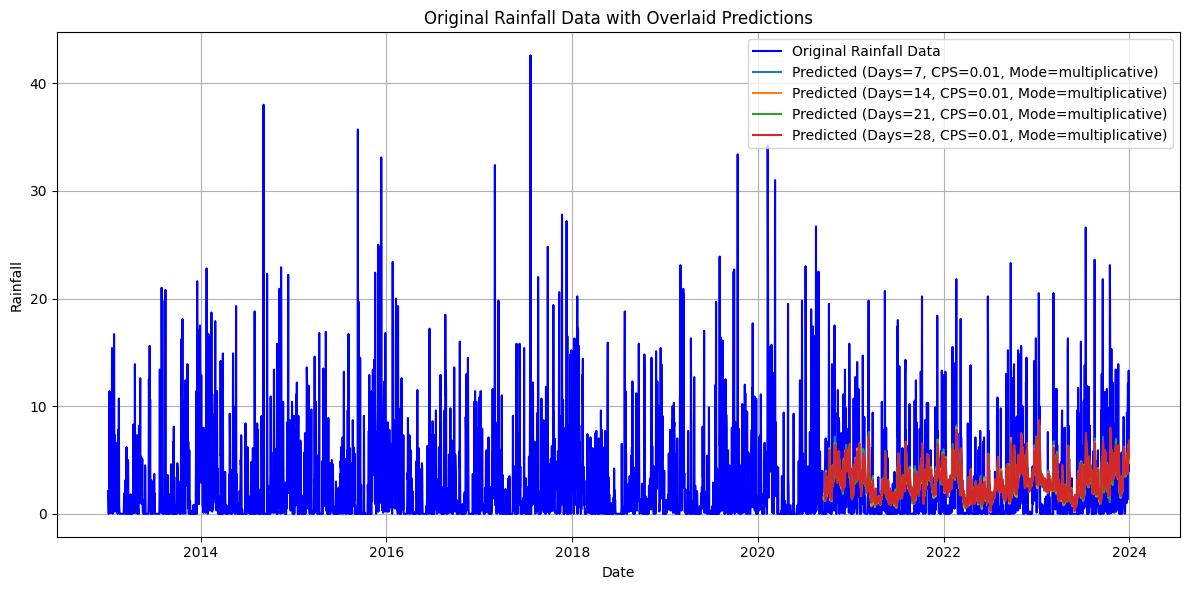

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from math import sqrt
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

changepoint_prior_scales = [0.01, 0.1, 0.5]
seasonality_modes = ['additive', 'multiplicative']
days_options = [7, 14, 21, 28]
explained_variance_thresholds = [0.85, 0.90, 0.95, 0.99]

results_summary = {}
best_config_per_days = {}

# Iterate over explained variance thresholds
for cps, sm, days, ev_threshold in itertools.product(changepoint_prior_scales, seasonality_modes, days_options, explained_variance_thresholds):

    df_original = county_clare.copy()
    df_original['date'] = pd.to_datetime(df_original['date'])
    df_original = df_original[['date', 'rain']].rename(columns={'date': 'ds', 'rain': 'y'})

    lag_column_names = []
    for i in range(1, days + 1):
        col_name = f'y_lag_{i}'
        df_original[col_name] = df_original['y'].shift(i)
        lag_column_names.append(col_name)

    df = df_original.dropna().copy()

    train_size = int(len(df) * 0.7)
    train_df = df.iloc[:train_size].copy()
    test_df = df.iloc[train_size:].copy()

    # --- PCA Dimensionality Reduction ---
    X_train_lags = train_df[lag_column_names]
    X_test_lags = test_df[lag_column_names]
    X_full_lags = df[lag_column_names]

    scaler = StandardScaler()
    X_train_lags_scaled = scaler.fit_transform(X_train_lags)
    X_test_lags_scaled = scaler.transform(X_test_lags)
    X_full_lags_scaled = scaler.transform(X_full_lags)

    pca = PCA(n_components=ev_threshold)
    X_train_pca = pca.fit_transform(X_train_lags_scaled)
    X_test_pca = pca.transform(X_test_lags_scaled)
    X_full_pca = pca.transform(X_full_lags_scaled)

    n_comp_actual = pca.n_components_

    pca_component_names = [f'PC{j+1}' for j in range(n_comp_actual)]

    train_df_pca = pd.DataFrame(X_train_pca, columns=pca_component_names, index=train_df.index)
    test_df_pca = pd.DataFrame(X_test_pca, columns=pca_component_names, index=test_df.index)
    df_pca_full = pd.DataFrame(X_full_pca, columns=pca_component_names, index=df.index)

    train_df = pd.concat([train_df.reset_index(drop=True), train_df_pca.reset_index(drop=True)], axis=1)
    test_df = pd.concat([test_df.reset_index(drop=True), test_df_pca.reset_index(drop=True)], axis=1)
    df_for_future_merge = pd.concat([df[['ds']].reset_index(drop=True), df_pca_full.reset_index(drop=True)], axis=1)

    model = Prophet(changepoint_prior_scale=cps, seasonality_mode=sm, daily_seasonality=True)

    for pc_name in pca_component_names:
        model.add_regressor(pc_name)

    model.fit(train_df[['ds', 'y'] + pca_component_names])

    future = model.make_future_dataframe(periods=len(test_df), freq='D')

    future = pd.merge(future, df_for_future_merge, on='ds', how='left')

    if future.isnull().any().any():
        print(f"Warning: NaNs found in future DataFrame for days={days}, ev_threshold={ev_threshold}, cps={cps}, sm={sm}. This might indicate an issue with how lagged features are being generated for the prediction horizon.")

    forecast = model.predict(future)

    merged = pd.merge(test_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='left')
    rmse = sqrt(mean_squared_error(merged['y'], merged['yhat']))

    # Store full result for later aggregation
    if days not in results_summary:
        results_summary[days] = []
    results_summary[days].append({
        'rmse': rmse,
        'cps': cps,
        'sm': sm,
        'ev_threshold': ev_threshold,
        'n_comp_actual': n_comp_actual,
        'actual': merged['y'],
        'predicted': merged['yhat'],
        'ds': merged['ds'],
        'days': days # <--- Added this line: Now the 'days' value is part of the dictionary
    })

# Summary stats and best config
print("\nDays | Mean RMSE | Std Dev RMSE")
print("-------------------------------")
for days, results in results_summary.items():
    rmses = [r['rmse'] for r in results]
    mean_rmse = np.mean(rmses)
    std_rmse = np.std(rmses)
    print(f"{days:<4} | {mean_rmse:.4f}   | {std_rmse:.4f}")
    best = min(results, key=lambda x: x['rmse'])
    best_config[days] = best

# Best configuration per days
print("\nBest Configuration per Days:")
print("Days | RMSE   | CPS   | Seasonality Mode")
print("----------------------------------------")
for days, config in best_config.items():
    print(f"{days:<4} | {config['rmse']:.4f} | {config['cps']:<5} | {config['sm']}")

# Plot the full original data
plt.figure(figsize=(12, 6))
plt.plot(county_clare['date'], county_clare['rain'], label='Original Rainfall Data', color='blue')

# Overlay predictions from best configurations
for days, config in best_config.items():
    plt.plot(config['ds'], config['predicted'], label=f'Predicted (Days={days}, CPS={config["cps"]}, Mode={config["sm"]})')

plt.title('Original Rainfall Data with Overlaid Predictions')
plt.xlabel('Date')
plt.ylabel('Rainfall')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Prophet with Autoencoder

Training Autoencoder for 7 days data (Input Dim: 112, Encoding Dim: 28)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean RMSE over all epochs for 7 days: 3.8049 (Std Dev: 0.2961)
RMSE on test set for 7 days: 4.4429
Training Autoencoder for 14 days data (Input Dim: 224, Encoding Dim: 56)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean RMSE over all epochs for 14 days: 3.5316 (Std Dev: 0.4091)
RMSE on test set for 14 days: 4.5487
Training Autoencoder for 21 days data (Input Dim: 336, Encoding Dim: 84)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 21 days: 3.0524 (Std Dev: 0.4746)
RMSE on test set for 21 days: 4.7741
Training Autoencoder for 28 days data (Input Dim: 448, Encoding Dim: 112)...
Autoencoder training complete.
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\meatefza\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean RMSE over all epochs for 28 days: 2.9589 (Std Dev: 0.5355)
RMSE on test set for 28 days: 4.5856


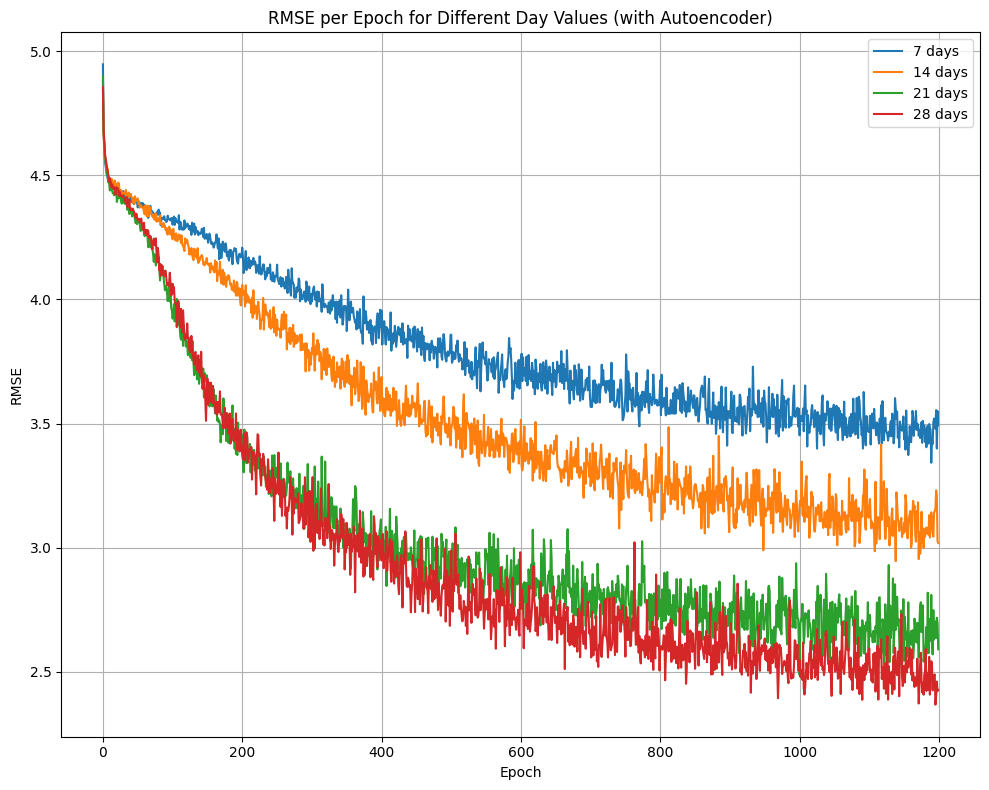

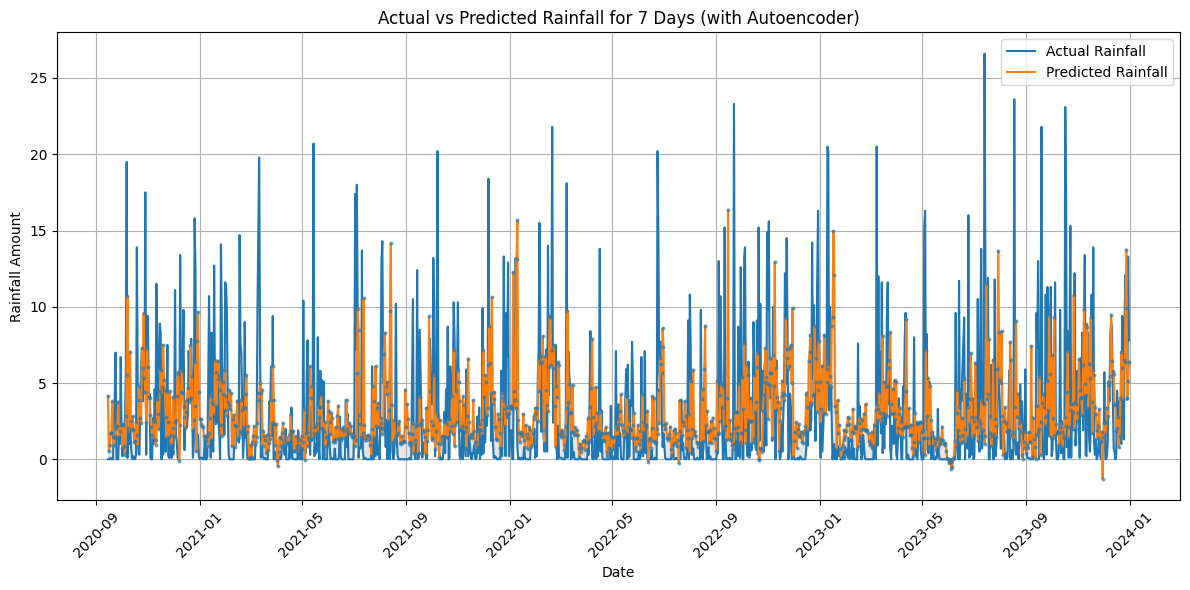

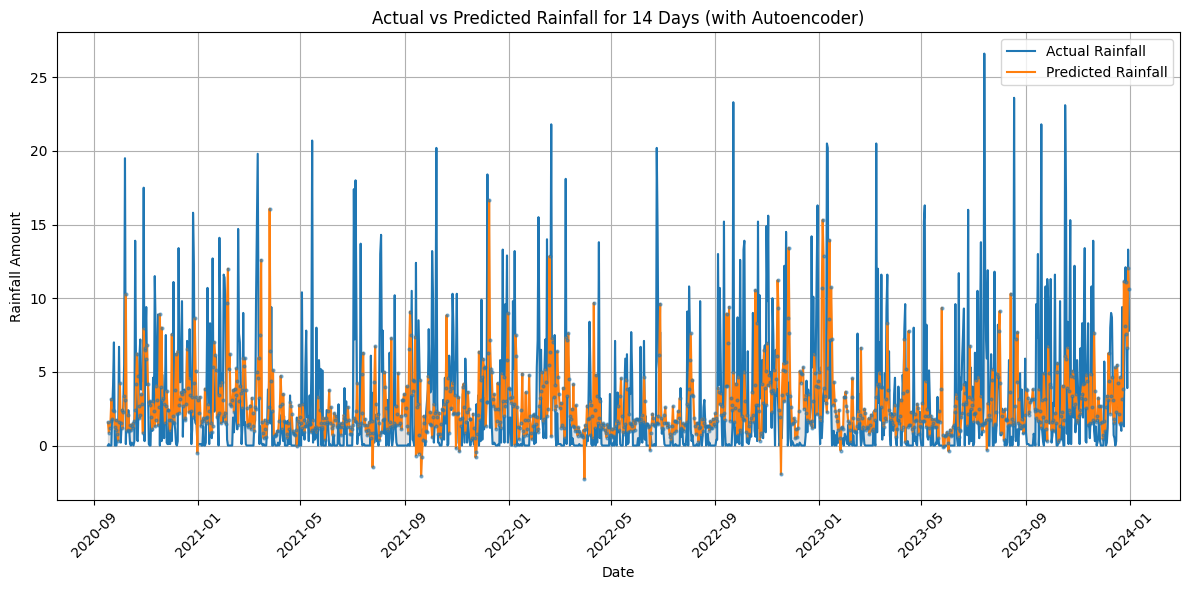

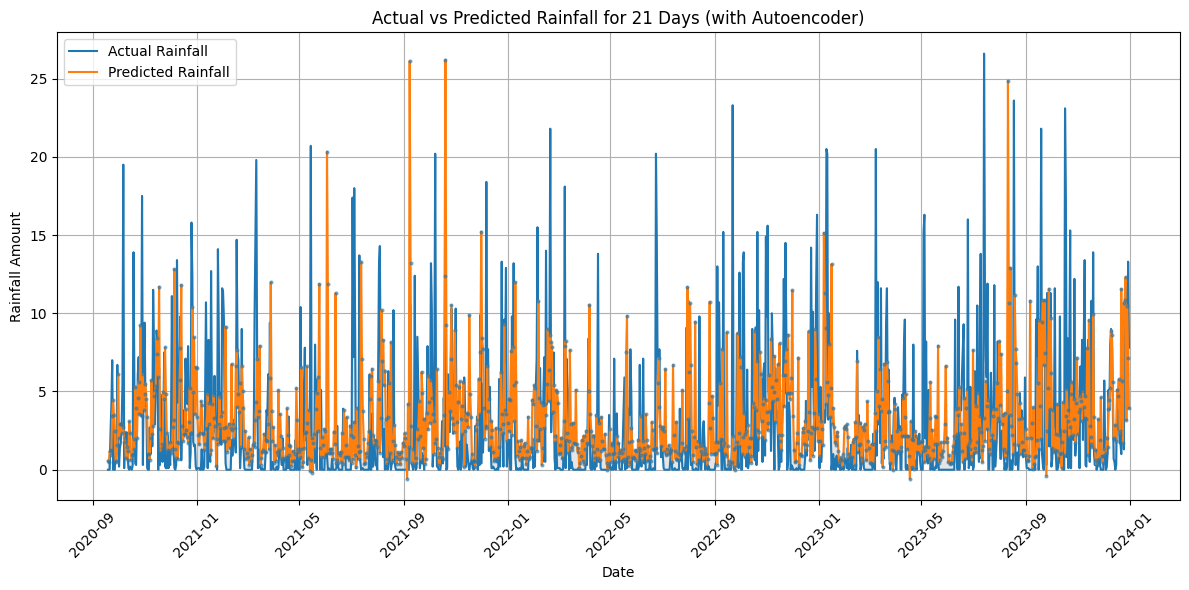

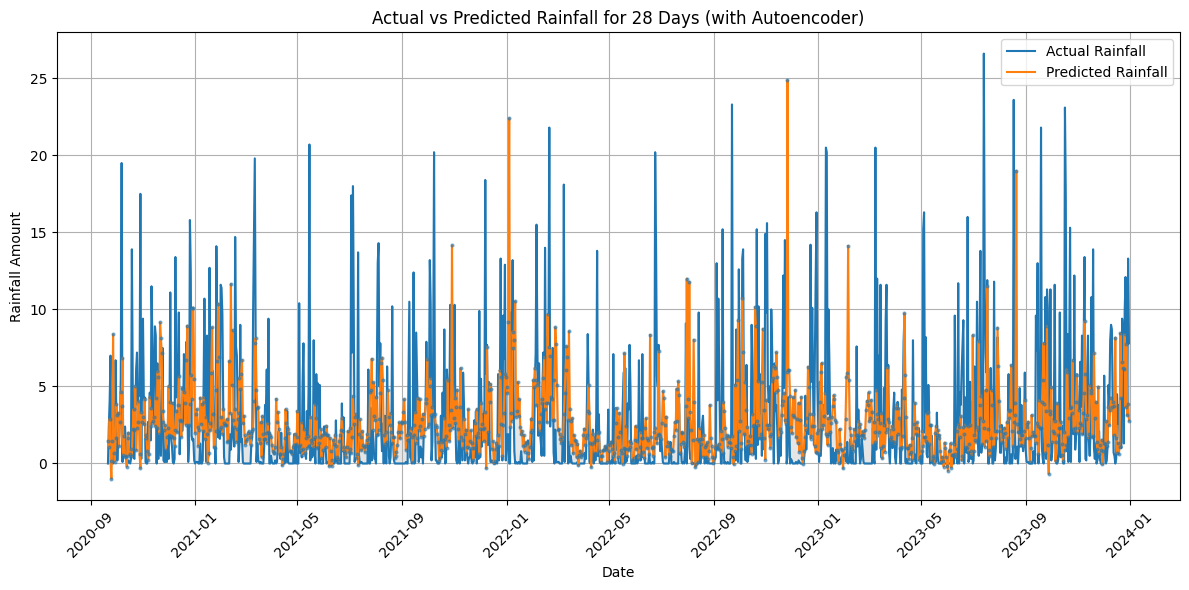


Summary of Mean and Standard Deviation of RMSE per Epoch:
Days Used | Mean RMSE | Std Dev RMSE
------------------------------------------
7          | 3.8049 | 0.2961
14         | 3.5316 | 0.4091
21         | 3.0524 | 0.4746
28         | 2.9589 | 0.5355


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
import matplotlib.pyplot as plt

# Initialise dictionaries to store RMSE values and all prediction dataframes
rmse_per_epoch_per_days = {}
final_rmse_summary = {}
all_predictions_df = {}

def create_autoencoder(input_dim, encoding_dim):
    input_layer = Input(shape=(input_dim,))
    encoder = Dense(encoding_dim * 2, activation='relu')(input_layer)
    encoder_output = Dense(encoding_dim, activation='relu')(encoder)
    decoder = Dense(encoding_dim * 2, activation='relu')(encoder_output)
    decoder_output = Dense(input_dim, activation='linear')(decoder)
    autoencoder = Model(inputs=input_layer, outputs=decoder_output)
    encoder_model = Model(inputs=input_layer, outputs=encoder_output)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    return autoencoder, encoder_model

def train_and_evaluate_model(days, original_df):
    tf.random.set_seed(42)
    np.random.seed(42)

    df = original_df.copy()
    target = 'rain'
    exclude_cols = [target, 'date']
    potential_features_to_lag = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    lagged_series_list = []
    for col in [target] + potential_features_to_lag:
        for i in range(1, days + 1):
            lagged_series = df[col].shift(i)
            lagged_series.name = f'{col}_previous_day_{i}'
            lagged_series_list.append(lagged_series)

    lagged_features_df = pd.concat(lagged_series_list, axis=1)
    df_with_lags = pd.concat([df, lagged_features_df], axis=1)
    df_with_lags.dropna(inplace=True)

    if 'date' in df_with_lags.columns:
        df_with_lags['date'] = pd.to_datetime(df_with_lags['date'])
        df_with_lags.set_index('date', inplace=True)

    features_to_use = [col for col in df_with_lags.columns if '_previous_day_' in col]
    X = df_with_lags[features_to_use]
    y = df_with_lags[target]

    train_size = int(len(df_with_lags) * 0.7)
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_test = X[train_size:]
    y_test = y[train_size:]

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    input_dim = X_train_scaled.shape[1]
    encoding_dim = max(8, input_dim // 4)

    print(f"Training Autoencoder for {days} days data (Input Dim: {input_dim}, Encoding Dim: {encoding_dim})...")
    autoencoder, encoder_model = create_autoencoder(input_dim, encoding_dim)

    autoencoder.fit(X_train_scaled, X_train_scaled,
                    epochs=100,
                    batch_size=32,
                    shuffle=True,
                    verbose=0,
                    validation_data=(X_test_scaled, X_test_scaled))
    print("Autoencoder training complete.")

    X_train_transformed = encoder_model.predict(X_train_scaled)
    X_test_transformed = encoder_model.predict(X_test_scaled)

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(encoding_dim,)))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')

    history = model.fit(X_train_transformed, y_train, epochs=1200, batch_size=32, verbose=0)

    y_pred = model.predict(X_test_transformed)
    mse_loss = MeanSquaredError()
    mse = mse_loss(y_test, y_pred)
    rmse_test_set = tf.sqrt(mse)

    rmse_values_per_epoch = np.sqrt(history.history['loss'])
    rmse_per_epoch_per_days[days] = rmse_values_per_epoch
    mean_rmse_epoch = np.mean(rmse_values_per_epoch)
    std_dev_rmse_epoch = np.std(rmse_values_per_epoch)

    final_rmse_summary[days] = {'mean': mean_rmse_epoch, 'std_dev': std_dev_rmse_epoch}

    print(f"Mean RMSE over all epochs for {days} days: {mean_rmse_epoch:.4f} (Std Dev: {std_dev_rmse_epoch:.4f})")
    print(f"RMSE on test set for {days} days: {rmse_test_set:.4f}")

    all_predictions_df[days] = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()}, index=y_test.index)

def plot_rmse_curves(rmse_per_epoch_per_days):
    plt.figure(figsize=(10, 8))
    for days, rmse_values in rmse_per_epoch_per_days.items():
        plt.plot(rmse_values, label=f'{days} days')
    plt.title('RMSE per Epoch for Different Day Values (with Autoencoder)')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_predictions(predictions_df, days):
    plt.figure(figsize=(12, 6))
    plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Rainfall', color='#1f77b4')
    plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Rainfall', color='#ff7f0e')
    plt.plot(predictions_df.index, predictions_df['Predicted'], 'o', markersize=2, alpha=0.5)
    plt.fill_between(predictions_df.index, predictions_df['Actual'], predictions_df['Predicted'], color='gray', alpha=0.2)
    plt.title(f'Actual vs Predicted Rainfall for {days} Days (with Autoencoder)')
    plt.xlabel('Date')
    plt.ylabel('Rainfall Amount')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Ensure the DataFrame 'county_clare' is loaded
for days in [7, 14, 21, 28]:
    train_and_evaluate_model(days, county_clare.copy())

plot_rmse_curves(rmse_per_epoch_per_days)

for days, df_predictions in all_predictions_df.items():
    plot_predictions(df_predictions, days)

print("\nSummary of Mean and Standard Deviation of RMSE per Epoch:")
print("Days Used | Mean RMSE | Std Dev RMSE")
print("------------------------------------------")
for days, metrics in final_rmse_summary.items():
    print(f"{days:<10} | {metrics['mean']:.4f} | {metrics['std_dev']:.4f}")
